In [ ]:
using CSV
using StatsKit
using Plots
using LsqFit
using Images
using Colors
using FileIO

## Stabilità dell'intensità luminosa

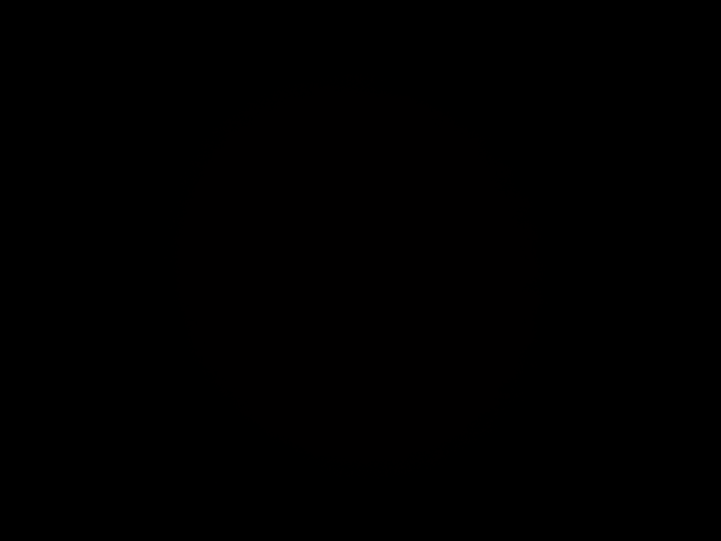

In [75]:
img = FileIO.load("dati/intensita/Snapshot_intensita_0001.tif")




## Calibrazione del primo polarizzatore

Il primo polarizzatore è montato su un supporto goniometrico che ne permette la rotazione precisa e la misura dell'angolo di orientazione. Poiché l'asse di trasmissione ottico del polarizzatore non è allineato con lo zero della scala angolare del goniometro, effettuiamo una procedura di calibrazione per determinare questa relazione angolare.

Misuriamo l'intensità luminosa $ I $ del fascio trasmesso in funzione dell'angolo $ \theta $ indicato dal goniometro in una serie di dati $ (\theta_i, I_i) $ a intervalli angolari regolari.

Il comportamento atteso è descritto dalla _legge di Malus_. Per tenere conto dello sfasamento strumentale e di eventuali offset sperimentali, utilizziamo il seguente modello
$$
I(\theta) = k I_0 \cdot \cos^2(\theta - \theta_{\text{offset}}) + I_{\text{offset}}
$$
dove $ I_0 $ è l'intensità luminosa del fascio in ingresso, e $ k $, $ \theta_{\text{offset}} $ e $ I_{\text{offset}} $ sono parametri determinati con il metodo dei minimi quadrati. 

In [3]:
index = 120:10:220

calibrazione_p1_df = CSV.read("calibrazione_p1/calibrazione_p1.csv", DataFrame)

calibrazione_p1_df[!, 1] = index

DataFrames.rename!(calibrazione_p1_df, 1 => :Angle)

Row,Angle,Area,Mean,Min,Max,IntDen,RawIntDen
,Int64,Int64,Float64,Int64,Int64,Float64,Float64
1,120,1555200,105.506,0,353,1.64083e8,1.64083e8
2,130,1555200,128.164,0,439,1.9932e8,1.9932e8
3,140,1555200,147.023,0,483,2.28651e8,2.28651e8
4,150,1555200,161.291,0,527,2.5084e8,2.5084e8
5,160,1555200,171.284,0,629,2.66381e8,2.66381e8
6,170,1555200,177.625,0,593,2.76243e8,2.76243e8
7,180,1555200,177.962,0,584,2.76766e8,2.76766e8
8,190,1555200,173.868,0,589,2.70399e8,2.70399e8
9,200,1555200,165.941,0,564,2.58072e8,2.58072e8


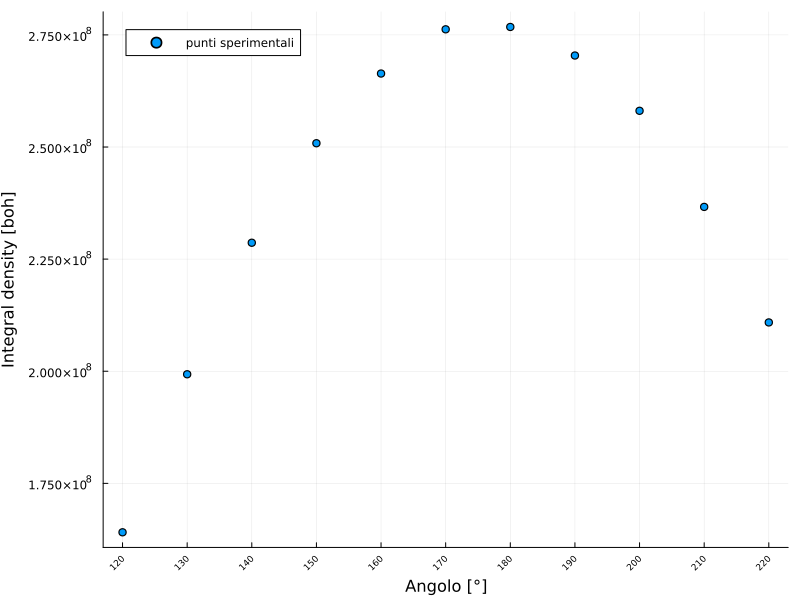

In [19]:
# Plotto i punti sperimentali

p = scatter(size=(800, 600), calibrazione_p1_df.Angle, calibrazione_p1_df.IntDen, label="punti sperimentali", xticks=calibrazione_p1_df.Angle, xrotation=45, xtickfontsize=6)
xlabel!("Angolo [°]")
ylabel!("Integral density [boh]")

In [17]:
# Fitto i punti con Malus

using LsqFit

x_axis = range(100, 230, length=100)

# Primo modello a due parametri
@. model(x, p) = p[1] * cos(x + p[2])^2 + p[3]

p0 = [1e8, π, 0]

fit = curve_fit(model, deg2rad.(calibrazione_p1_df.Angle), calibrazione_p1_df.IntDen, p0)

LsqFit.LsqFitResult{Vector{Float64}, Vector{Float64}, Matrix{Float64}, Vector{Float64}, Vector{LsqFit.LMState{LsqFit.LevenbergMarquardt}}}([1.5450509193679228e8, 3.189707558426146, 1.2579478753326431e8], [6.944404923476845e6, -2.3158788564655185e6, -4.9409654479904175e6, -2.9173352700937986e6, 342382.1457642615, 1.6008018826945424e6, 3.176688308089733e6, 2.3676595038901567e6, -890369.1676547229, -1.5767869201559424e6, -1.7906011402135491e6], [0.29276107876503055 1.4060881179057923e8 1.000000000000401; 0.46088843882148606 1.540316693121665e8 1.000000000000401; … ; 0.7072389212417175 -1.4060881178749332e8 1.000000000000401; 0.5391115612011889 -1.5403166931293797e8 1.000000000000401], true, Iter     Function value   Gradient norm 
------   --------------   --------------
, Float64[])

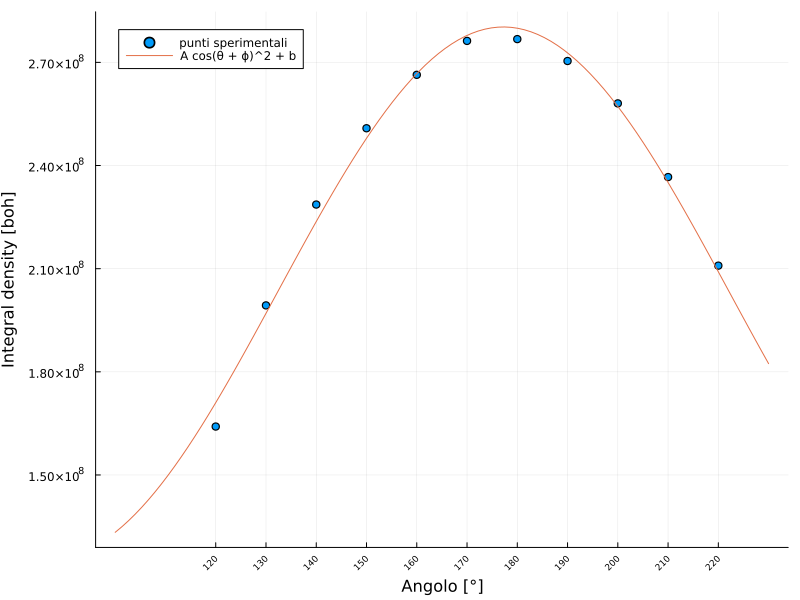

In [20]:
# Plotto la curva a tre parametri fittata
plot(p, x_axis, model(deg2rad.(x_axis), fit.param), label="A cos(θ + ϕ)^2 + b")

In [11]:
# Trovo il massimo

using Optim

f = x -> -model(x[1], fit.param)[1]

res = optimize(f, [deg2rad(175)])

@show rad2deg.(Optim.minimizer(res))

rad2deg.(Optim.minimizer(res)) = [177.24321881096506]


1-element Vector{Float64}:
 177.24321881096506

# Calibrazione del secondo polarizzatore

Stesse considerazioni fatte per il primo polarizzatore.

In [23]:
index = 130:10:240

calibrazione_p2_df = CSV.read("calibrazione_p2/calibrazione_p2.csv", DataFrame)

calibrazione_p2_df[!, 1] = index

DataFrames.rename!(calibrazione_p2_df, 1 => :Angle)

Row,Angle,Area,Mean,Min,Max,IntDen,RawIntDen
,Int64,Int64,Float64,Int64,Int64,Float64,Float64
1,130,1555200,115.553,0,413,1.79708e8,1.79708e8
2,140,1555200,132.311,0,482,2.05769e8,2.05769e8
3,150,1555200,145.909,0,520,2.26917e8,2.26917e8
4,160,1555200,154.938,0,560,2.40959e8,2.40959e8
5,170,1555200,160.581,0,572,2.49736e8,2.49736e8
6,180,1555200,161.391,0,554,2.50996e8,2.50996e8
7,190,1555200,157.643,0,566,2.45167e8,2.45167e8
8,200,1555200,149.991,0,527,2.33266e8,2.33266e8
9,210,1555200,138.047,0,483,2.1469e8,2.1469e8


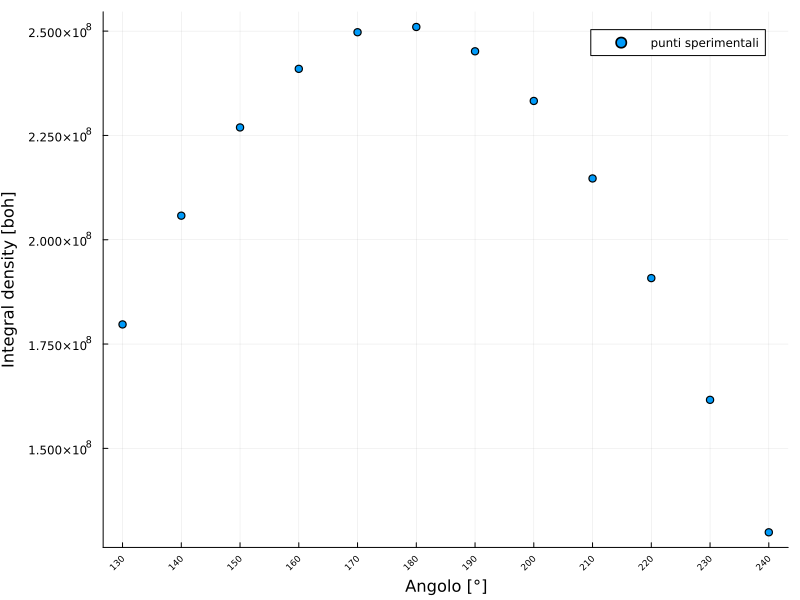

In [24]:
# Plotto i punti sperimentali

p = scatter(size=(800, 600), calibrazione_p2_df.Angle, calibrazione_p2_df.IntDen, label="punti sperimentali", xticks=calibrazione_p2_df.Angle, xrotation=45, xtickfontsize=6)
xlabel!("Angolo [°]")
ylabel!("Integral density [boh]")

rad2deg.((Optim.minimizer(res))[1]) = 176.53043544785834
plot(p, x_axis, model(deg2rad.(x_axis), fit.param), label = "A cos(θ + ϕ)^2 + b") = Plot{Plots.GRBackend() n=2}


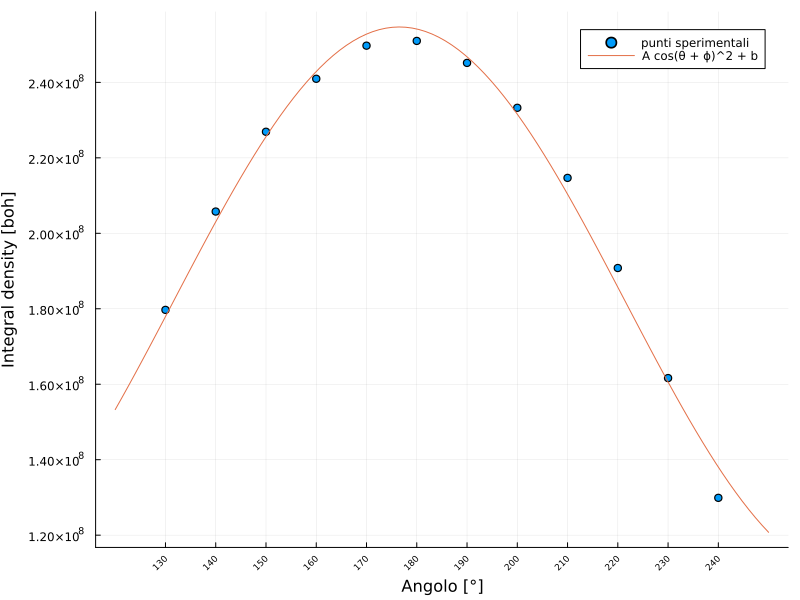

In [31]:
# Fitto i punti con Malus
using LsqFit

x_axis = range(120, 250, length=100)

@. model(x, p) = p[1] * cos(x + p[2])^2 + p[3]

p0 = [1e8, π, 0]

fit = curve_fit(model, deg2rad.(calibrazione_p2_df.Angle), calibrazione_p2_df.IntDen, p0)

# Trovo il massimo
using Optim

f = x -> -model(x[1], fit.param)[1]

res = optimize(f, [deg2rad(180)])

@show rad2deg.(Optim.minimizer(res)[1])


# Plotto la curva a tre parametri fittata
@show plot(p, x_axis, model(deg2rad.(x_axis), fit.param), label="A cos(θ + ϕ)^2 + b")

## Verifica della legge di Malus

In [43]:
index = -30:15:195

malus_df = CSV.read("malus/malus.csv", DataFrame)

malus_df[!, 1] = index

DataFrames.rename!(malus_df, 1 => :Angle)

Row,Angle,Area,Mean,Min,Max,IntDen,RawIntDen
,Int64,Int64,Float64,Int64,Int64,Float64,Float64
1,-30,1555200,124.015,0,454,1.92868e8,1.92868e8
2,-15,1555200,94.973,0,316,1.47702e8,1.47702e8
3,0,1555200,145.61,0,524,2.26453e8,2.26453e8
4,15,1555200,158.12,0,549,2.45908e8,2.45908e8
5,30,1555200,161.727,0,549,2.51518e8,2.51518e8
6,45,1555200,155.396,0,562,2.41671e8,2.41671e8
7,60,1555200,139.325,0,489,2.16678e8,2.16678e8
8,75,1555200,115.342,0,405,1.79379e8,1.79379e8
9,90,1555200,84.821,0,277,1.31914e8,1.31914e8


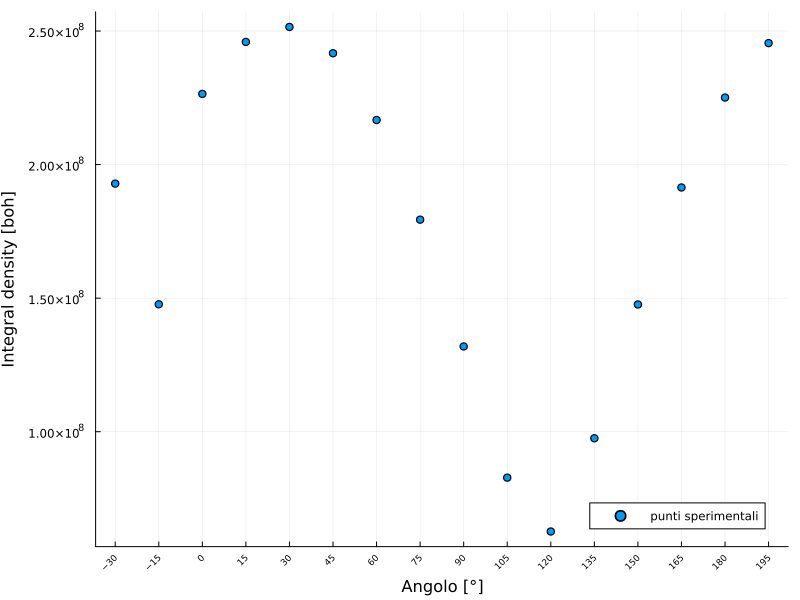

In [44]:
# Plotto i punti sperimentali

p = scatter(size=(800, 600), malus_df.Angle, malus_df.IntDen, label="punti sperimentali", xticks=malus_df.Angle, xrotation=45, xtickfontsize=6)
xlabel!("Angolo [°]")
ylabel!("Integral density [boh]")

rad2deg.((Optim.minimizer(res))[1]) = 117.02349220347358
plot(p, x_axis, model(deg2rad.(x_axis), fit.param), label = "A cos(θ + ϕ)^2 + b") = Plot{Plots.GRBackend() n=2}


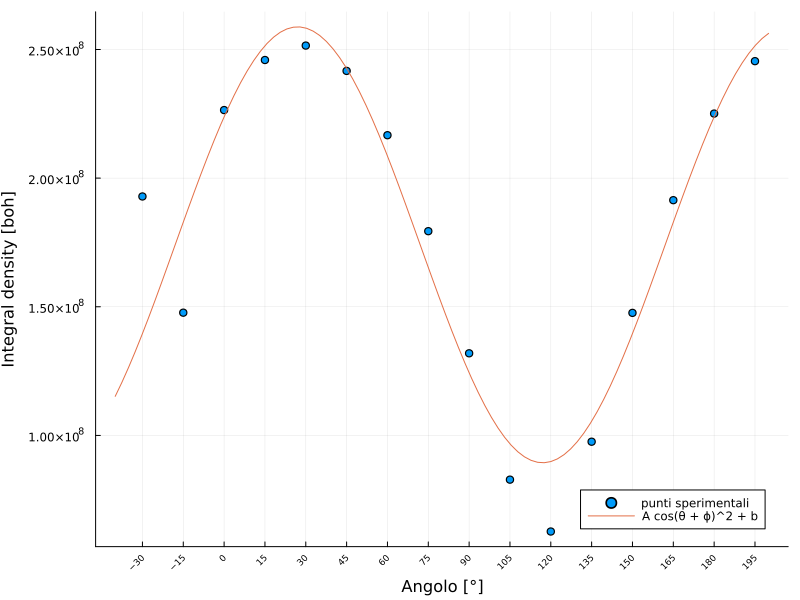

In [46]:
# Fitto i punti con Malus
using LsqFit

x_axis = range(-40, 200, length=100)

@. model(x, p) = p[1] * cos(x + p[2])^2 + p[3]

p0 = [1e8, π, 0]

fit = curve_fit(model, deg2rad.(malus_df.Angle), malus_df.IntDen, p0)

# Trovo il minimo
using Optim

f = x -> model(x[1], fit.param)[1]

res = optimize(f, [deg2rad(120)])

@show rad2deg.(Optim.minimizer(res)[1])


# Plotto la curva a tre parametri fittata
@show plot(p, x_axis, model(deg2rad.(x_axis), fit.param), label="A cos(θ + ϕ)^2 + b")

## Lamina $ \lambda / 2 $

In [47]:
index = 0:10:90

lambdamezzi_df = CSV.read("lambdamezzi/lambdamezzi.csv", DataFrame)

lambdamezzi_df[!, 1] = index

DataFrames.rename!(lambdamezzi_df, 1 => :Angle)

Row,Angle,Area,Mean,Min,Max,IntDen,RawIntDen
,Int64,Int64,Float64,Int64,Int64,Float64,Float64
1,0,1555200,118.571,0,445,1.84401e8,1.84401e8
2,10,1555200,147.752,0,549,2.29784e8,2.29784e8
3,20,1555200,160.076,0,593,2.4895e8,2.4895e8
4,30,1555200,155.287,0,577,2.41503e8,2.41503e8
5,40,1555200,133.973,0,462,2.08356e8,2.08356e8
6,50,1555200,98.519,0,330,1.53217e8,1.53217e8
7,60,1555200,56.594,0,205,8.80143e7,8.80143e7
8,70,1555200,42.185,0,205,6.5606e7,6.5606e7
9,80,1555200,79.897,0,265,1.24256e8,1.24256e8


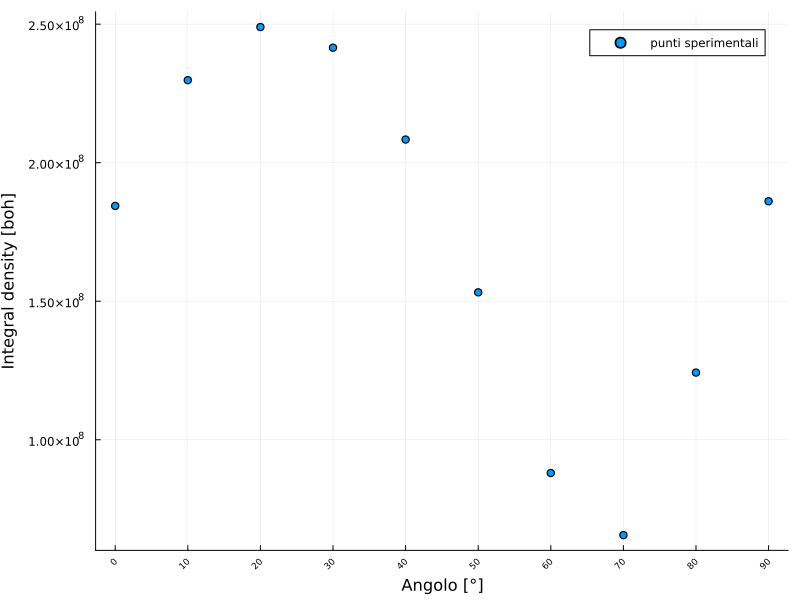

In [48]:
# Plotto i punti sperimentali

p = scatter(size=(800, 600), lambdamezzi_df.Angle, lambdamezzi_df.IntDen, label="punti sperimentali", xticks=lambdamezzi_df.Angle, xrotation=45, xtickfontsize=6)
xlabel!("Angolo [°]")
ylabel!("Integral density [boh]")

rad2deg.((Optim.minimizer(res))[1]) = 66.81832551678379
rad2deg.((Optim.minimizer(res))[1]) = 22.095032059768936
plot(p, x_axis, model(deg2rad.(x_axis), fit.param), label = "A cos(θ + ϕ)^2 + b") = Plot{Plots.GRBackend() n=2}


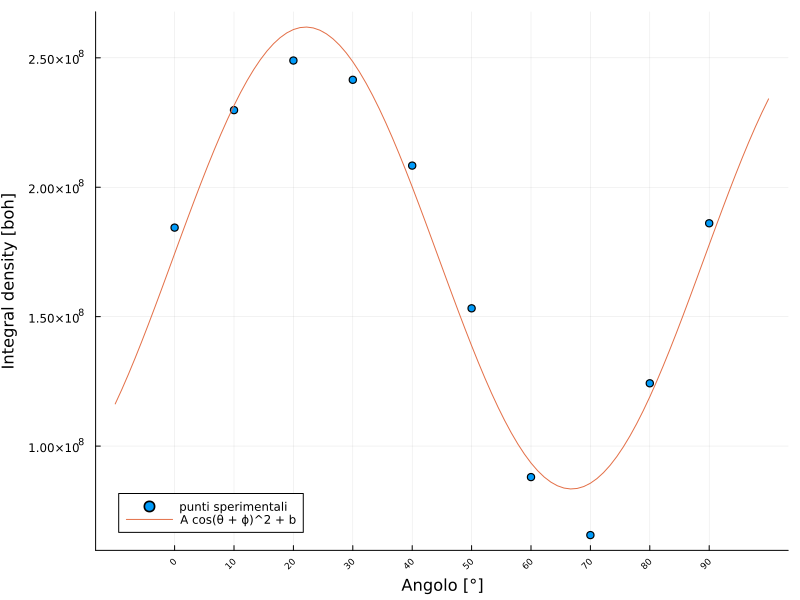

In [60]:
# Fitto i punti con Malus
using LsqFit

x_axis = range(-10, 100, length=100)

@. model(x, p) = p[1] * cos(p[4]*x + p[2])^2 + p[3]

p0 = [1e8, π/2, 0, 1]

fit = curve_fit(model, deg2rad.(lambdamezzi_df.Angle), lambdamezzi_df.IntDen, p0)

# Trovo il minimo
using Optim

f = x -> model(x[1], fit.param)[1]
res = optimize(f, [deg2rad(70)])
@show rad2deg.(Optim.minimizer(res)[1])

g = x -> -model(x[1], fit.param)[1]
res = optimize(g, [deg2rad(20)])
@show rad2deg.(Optim.minimizer(res)[1])


# Plotto la curva a tre parametri fittata
@show plot(p, x_axis, model(deg2rad.(x_axis), fit.param), label="A cos(θ + ϕ)^2 + b")

In [55]:
fit.param

4-element Vector{Float64}:
 1.784599319411056e8
 2.365558657899553
 8.342810566315365e7
 2.0123741789573852